In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
data  = np.genfromtxt('training-val-test-data.csv', delimiter=',', skip_header=1)
u_all  = data[:, 0]   # input voltage [V]
th_all = data[:, 1]   # disk angle [rad]

N = len(u_all)
print(f"Samples: {N}")
print(f"u  — min: {u_all.min():.3f} V,  max: {u_all.max():.3f} V")
print(f"θ  — min: {np.degrees(th_all.min()):.1f}°,  max: {np.degrees(th_all.max()):.1f}°,  std: {np.degrees(th_all.std()):.1f}°")

Samples: 35000
u  — min: -3.103 V,  max: 3.337 V
θ  — min: -108.9°,  max: 124.9°,  std: 27.5°


In [3]:
# We create contiguous sets to avoid data leakage
split_train = int(0.70 * N) 
split_val   = int(0.85 * N)  

u_train,  th_train  = u_all[:split_train],          th_all[:split_train]
u_val,    th_val    = u_all[split_train:split_val],  th_all[split_train:split_val]
u_test,   th_test   = u_all[split_val:],             th_all[split_val:]

print(f"Training  : {len(u_train):>6} samples")
print(f"Validation: {len(u_val):>6} samples")
print(f"Test      : {len(u_test):>6} samples")

Training  :  24500 samples
Validation:   5250 samples
Test      :   5250 samples


### Time domain plot

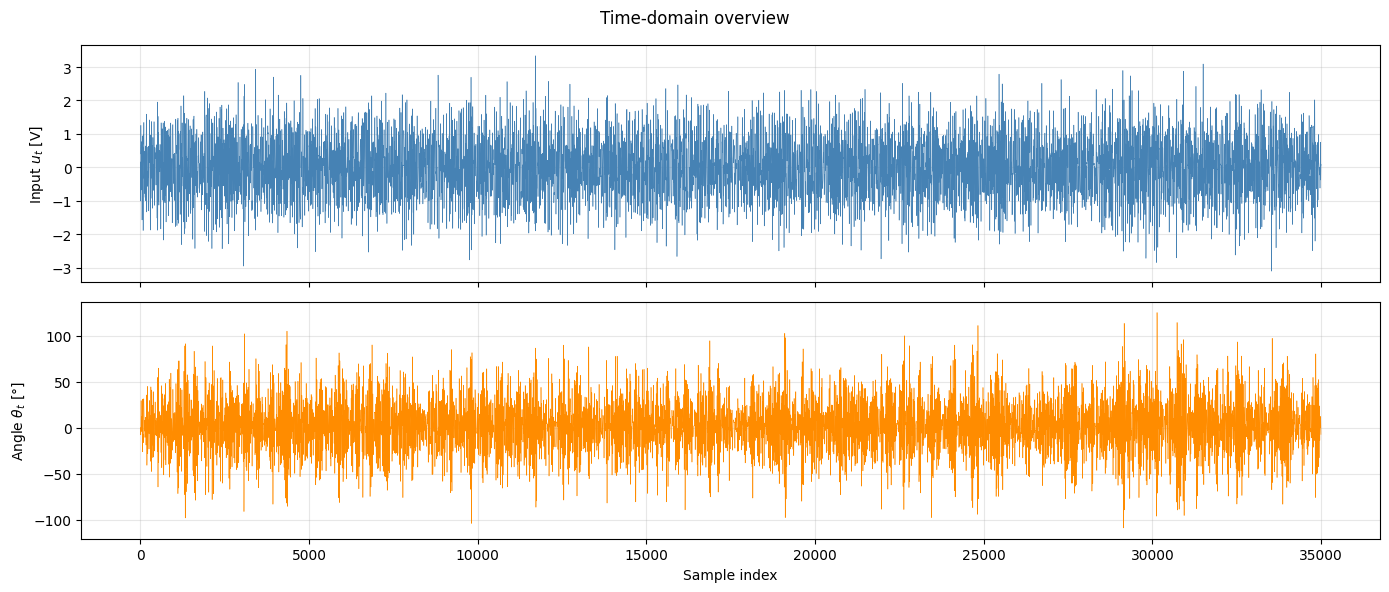

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(u_all, lw=0.4, color='steelblue')
axes[0].set_ylabel("Input $u_t$ [V]") 
axes[0].grid(alpha=0.3)
axes[1].plot(np.degrees(th_all), lw=0.4, color='darkorange')
axes[1].set_ylabel("Angle $\\theta_t$ [°]"); 
axes[1].set_xlabel("Sample index")
axes[1].grid(alpha=0.3)
plt.suptitle("Time-domain overview", fontsize=12)
plt.tight_layout(); plt.show()

### Histogram of θ

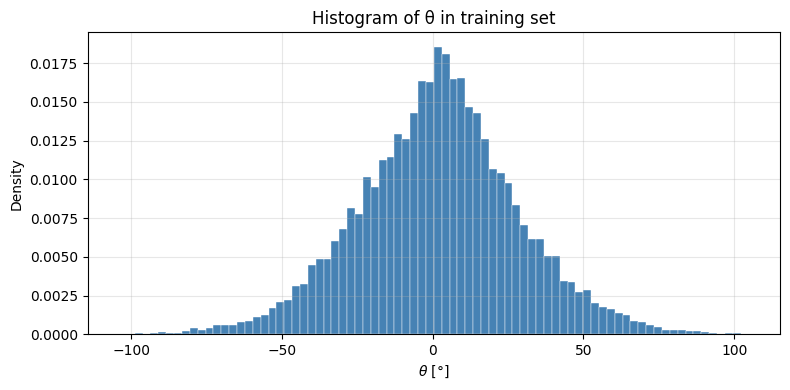

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(np.degrees(th_train), bins=80, density=True,
        color='steelblue', edgecolor='white', linewidth=0.3)

ax.set_xlabel("$\\theta$ [°]"); ax.set_ylabel("Density")
ax.set_title("Histogram of θ in training set")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Noise Level Estimation

In [6]:
# Variance of Δθ on Near-static segments ≈ 2σ_e²  (differencing doubles the noise variance)
static_mask = np.abs(u_train[1:]) < 0.1
dth_static  = np.diff(th_train)[static_mask]

sigma_e_est  = np.std(dth_static) / np.sqrt(2)
sigma_e2_est = sigma_e_est ** 2

print(f"Near-static samples used: {static_mask.sum()}")
print(f"Estimated σ_e  ≈ {sigma_e_est:.5f} rad  ({np.degrees(sigma_e_est):.3f}°)")
print(f"Estimated σ_e² ≈ {sigma_e2_est:.6f} rad²")

Near-static samples used: 2306
Estimated σ_e  ≈ 0.08291 rad  (4.750°)
Estimated σ_e² ≈ 0.006874 rad²


### NARX construction

In [7]:
def make_training_data(u, th, na, nb):
    X, Y = [], []
    for k in range(max(na, nb), len(u)):
        th_feat = [th[k-na+i] for i in range(na)]
        u_feat = [u[k-nb+i] for i in range(nb)]
        X.append(th_feat + u_feat)
        Y.append(th[k])
    return np.array(X), np.array(Y)

na, nb = 4, 2

Xtrain, Ytrain = make_training_data(u_train, th_train, na, nb)
Xval,   Yval   = make_training_data(u_val,   th_val,   na, nb)

print(f"Xtrain shape: {Xtrain.shape}")
print(f"Xval shape: {Xval.shape}")
print(f"Ytrain shape {Ytrain.shape}")
print(f"Ytrain shape {Yval.shape}")

Xtrain shape: (24496, 6)
Xval shape: (5246, 6)
Ytrain shape (24496,)
Ytrain shape (5246,)


## Normalization

In [8]:
from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
scaler_y = StandardScaler()

Xtrain_s = scaler_x.fit_transform(Xtrain)
Ytrain_s = scaler_y.fit_transform(Ytrain.reshape(-1,1))

Xval_s = scaler_x.transform(Xval)
Yval_s = scaler_y.transform(Yval.reshape(-1,1))

### Best Fit Rate

In [9]:
# Best Fit Rate (BFR) metric

def BFR(y_true, y_pred):
    num = np.sqrt(np.sum((y_true - y_pred)**2))
    den = np.sqrt(np.sum((y_true - np.mean(y_true))**2))
    return 100 * max(1 - num/den, 0)

def RMSE(ytrue, ypred):
    return np.sqrt(np.mean((ytrue-ypred)**2))

In [10]:
print("Xtrain_s stats (should be ~mean=0, std=1):")
print(f"  mean: {Xtrain_s.mean(axis=0).round(3)}")
print(f"  std:  {Xtrain_s.std(axis=0).round(3)}")

print("\nYtrain_s stats:")
print(f"  mean: {Ytrain_s.mean():.3f}  (should be ~0)")
print(f"  std:  {Ytrain_s.std():.3f}   (should be ~1)")

print("\nXval_s stats (should be close to 0 mean, ~1 std):")
print(f"  mean: {Xval_s.mean(axis=0).round(3)}")
print(f"  std:  {Xval_s.std(axis=0).round(3)}")

Xtrain_s stats (should be ~mean=0, std=1):
  mean: [ 0.  0.  0.  0.  0. -0.]
  std:  [1. 1. 1. 1. 1. 1.]

Ytrain_s stats:
  mean: 0.000  (should be ~0)
  std:  1.000   (should be ~1)

Xval_s stats (should be close to 0 mean, ~1 std):
  mean: [-0.004 -0.004 -0.004 -0.004  0.001  0.   ]
  std:  [1.052 1.052 1.052 1.052 1.012 1.012]


### Baseline GP with 500 samples

In [11]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

ker = RBF(length_scale=0.5) + WhiteKernel(noise_level=sigma_e2_est)
reg = GaussianProcessRegressor(ker, n_restarts_optimizer=3)
reg.fit(Xtrain[:1000], Ytrain[:1000])

Ypred_val = reg.predict(Xval[:400])
print(f"Baseline BFR: {BFR(Yval[:400], Ypred_val):.1f}%")
print(f"Baseline RMSE: {RMSE(Yval[:400], Ypred_val)}")
print(f"Optimised kernel: {reg.kernel_}")

Baseline BFR: 97.1%
Baseline RMSE: 0.020043079202231563
Optimised kernel: RBF(length_scale=3.07) + WhiteKernel(noise_level=1.13e-05)


### $n_a$ sweep

In [13]:
na_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
bfr_results = {}

for na_now in na_list:
    X_sw, Y_sw = make_training_data(u_train[:2002], th_train[:2002], na=na_now, nb=1)
    X_vw, Y_vw = make_training_data(u_val[:802],   th_val[:802],   na=na_now, nb=1)

    ker_sw = RBF(length_scale=0.5) + WhiteKernel(noise_level=sigma_e2_est)
    reg_sw = GaussianProcessRegressor(ker_sw, n_restarts_optimizer=3)
    reg_sw.fit(X_sw, Y_sw)

    Yp_vw = reg_sw.predict(X_vw)
    bfr_results[na_now] = BFR(Y_vw, Yp_vw)
    print(f"na={na_now}: prediction BFR = {bfr_results[na_now]:.1f}%")

na=1: prediction BFR = 77.0%
na=2: prediction BFR = 98.5%
na=3: prediction BFR = 98.9%
na=4: prediction BFR = 99.1%
na=5: prediction BFR = 99.0%
na=6: prediction BFR = 99.0%
na=7: prediction BFR = 99.1%
na=8: prediction BFR = 99.1%


c:\Users\konst\miniconda3\envs\gpy_env\Lib\site-packages\sklearn\gaussian_process\_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


na=9: prediction BFR = 99.1%
na=10: prediction BFR = 99.1%


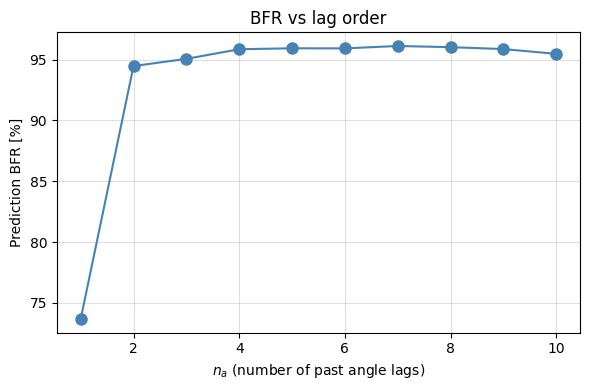

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(na_list, [bfr_results[n] for n in na_list], 'o-', color='steelblue', ms=8)
ax.set_xlabel("$n_a$ (number of past angle lags)")
ax.set_ylabel("Prediction BFR [%]")
ax.set_title("BFR vs lag order")

ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [10]:
# From Exercise 5 Cell 48 pattern: plot measured vs predicted with uncertainty bars
# Uses the baseline reg fitted in Cell 3

Ypred_plot, Ystd_plot = reg.predict(Xval[:150], return_std=True)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.degrees(Yval[:150]), 'b', lw=1.5, label='measured $\\theta_t$')
ax.errorbar(np.arange(150), np.degrees(Ypred_plot),
            yerr=2*np.degrees(Ystd_plot),
            fmt='.r', ms=3, elinewidth=0.5, capsize=2,
            label='GP prediction ± 2σ')
ax.set_xlabel("Sample index"); ax.set_ylabel("$\\theta$ [°]")
ax.set_title("Step 2 — One-step-ahead prediction on validation set\n"
             "(na=2, nb=1, small subset GP — sanity check)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Prediction BFR on validation: {BFR(Yval[:150], Ypred_plot):.1f}%")

NameError: name 'reg' is not defined

## Kernel Choice

In [34]:
from sklearn.gaussian_process.kernels import ExpSineSquared
#kernel = RBF(length_scale=[1.0, 1.0, 1.0, 1.0, 1.5]) + WhiteKernel(noise_level=sigma_e2_est)
kernel = (RBF(length_scale=[1.0]*(na+nb)) * ExpSineSquared(length_scale=1.0, periodicity=2*np.pi)) \
    + RBF(length_scale=[1.0]*(na+nb))+  WhiteKernel(noise_level=sigma_e2_est)

reg = GaussianProcessRegressor(kernel, n_restarts_optimizer=10)
reg.fit(Xtrain[:500], Ytrain[:500])

Ypred_val = reg.predict(Xval[:200])
print(f"Baseline BFR: {BFR(Yval[:200], Ypred_val):.1f}%")
print(f"Optimised kernel: {reg.kernel_}")

Baseline BFR: 95.7%
Optimised kernel: RBF(length_scale=[304, 291, 306, 229, 39, 116]) * ExpSineSquared(length_scale=171, periodicity=393) + RBF(length_scale=[2.08, 4.4, 3.49, 1.4, 83.8, 2.16e+04]) + WhiteKernel(noise_level=1.28e-05)


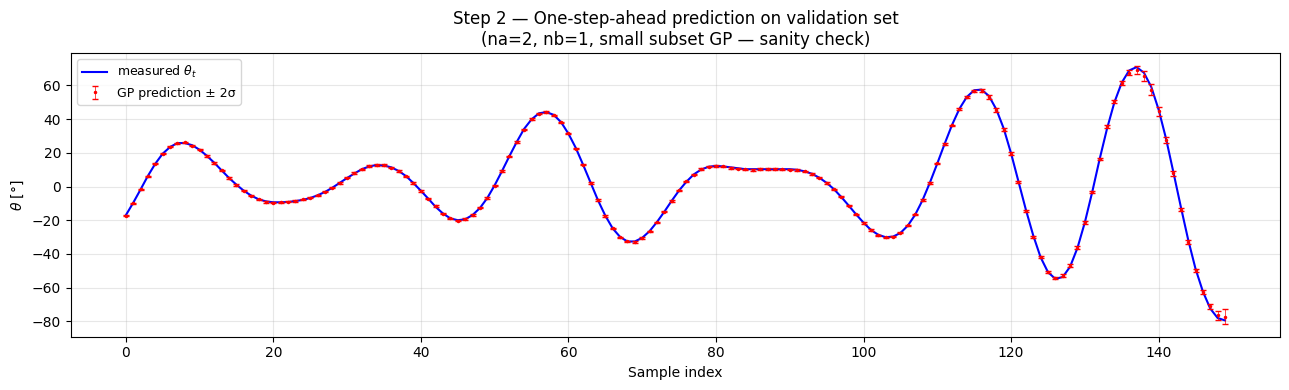

Prediction BFR on validation: 98.2%
Prediction RMSE on validation: 0.00902447242837269


In [35]:
# From Exercise 5 Cell 48 pattern: plot measured vs predicted with uncertainty bars
# Uses the baseline reg fitted in Cell 3

Ypred_plot, Ystd_plot = reg.predict(Xval[:150], return_std=True)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.degrees(Yval[:150]), 'b', lw=1.5, label='measured $\\theta_t$')
ax.errorbar(np.arange(150), np.degrees(Ypred_plot),
            yerr=2*np.degrees(Ystd_plot),
            fmt='.r', ms=3, elinewidth=0.5, capsize=2,
            label='GP prediction ± 2σ')
ax.set_xlabel("Sample index"); ax.set_ylabel("$\\theta$ [°]")
ax.set_title("Step 2 — One-step-ahead prediction on validation set\n"
             "(na=2, nb=1, small subset GP — sanity check)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Prediction BFR on validation: {BFR(Yval[:150], Ypred_plot):.1f}%")
print(f"Prediction RMSE on validation: {RMSE(Yval[:150], Ypred_plot)}")

## Sparse GP case

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import GPy
from GPy.inference.latent_function_inference import VarDTC

M=200
kernel_theta = GPy.kern.StdPeriodic(
    input_dim=na,
    active_dims=list(range(na)),
    period=2*np.pi
)

kernel_theta2 = GPy.kern.RBF(
    input_dim=na,
    active_dims=list(range(na)),
    ARD=True
)

kernel_u = GPy.kern.RBF(
    input_dim=nb,
    active_dims=list(range(na, na + nb))
)

kernel = kernel_theta*kernel_theta2 + kernel_u
idx = np.random.choice(len(Xtrain), M, replace=False)
Z = Xtrain[idx].copy()

m_sparse = GPy.models.SparseGPRegression(Xtrain,Ytrain.reshape(-1,1),Z=Z, kernel=kernel)
m_sparse.inference_method = VarDTC()
m_sparse.likelihood.variance = sigma_e2_est
m_sparse.Z.unconstrain()
m_sparse.optimize('bfgs', messages=True)
#m.plot()
print(m_sparse)



Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    22s64  0007  -8.095339e+04   2.453876e+09 
 01m09s86  0022  -1.023563e+05   3.340940e+07 
 02m49s46  0054  -1.026566e+05   1.824585e+08 
Runtime:  02m49s46
Optimization status: Converged


Name : sparse_gp
Objective : -102656.61703851819
Number of Parameters : 1211
Number of Optimization Parameters : 1211
Updates : True
Parameters:
  sparse_gp.                        |                   value  |  constraints  |  priors
  inducing_inputs                   |                (200, 6)  |               |        
  sum.mul.std_periodic.variance     |      0.4188773480330013  |      +ve      |        
  sum.mul.std_periodic.period       |       6.778644659816516  |      +ve      |        
  sum.mul.std_periodic.lengthscale  |      2.0811991363411297  |      +ve      |        
  sum.mul.rbf.variance              |      0.4188773480630045  |      +ve      |        
  sum.mul.rbf.lengthscale           

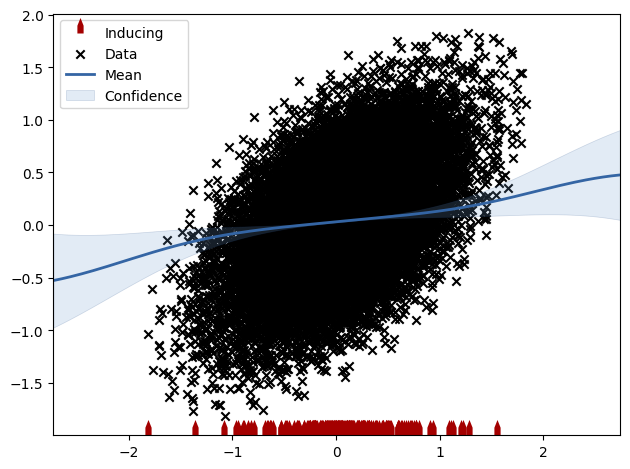

In [13]:
fixed_inputs = [(i, float(Xtrain[:, i].mean())) for i in range(1, na+nb)]
m_sparse.plot(visible_dims=[0], fixed_inputs=fixed_inputs)
plt.show()

### Prediction of the validation test for GP-NARX

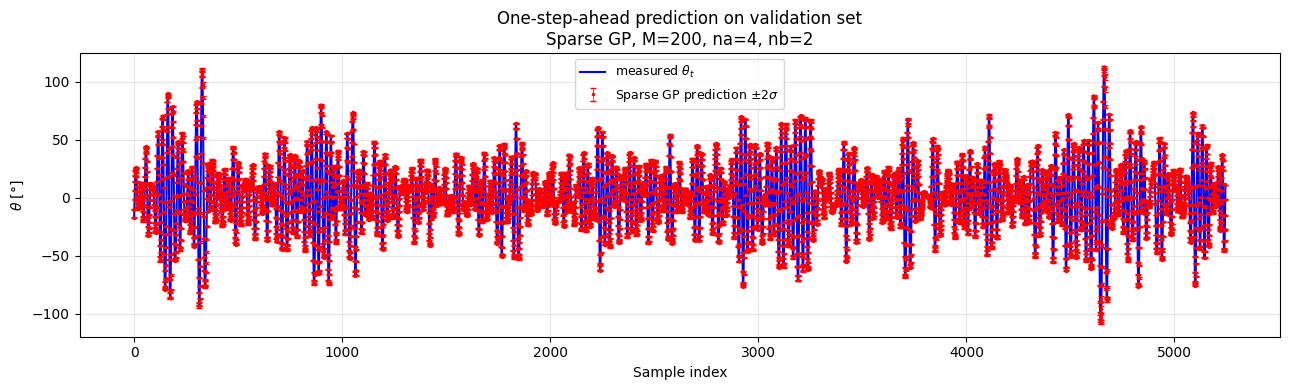

Prediction BFR on validation:  99.3%
Prediction RMSE on validation: 0.00366 rad
Prediction RMSE on validation: 0.210 deg
NRMS: 0.7435919609262011 %


In [14]:
# -----------------------------
# One-step-ahead prediction plot
# -----------------------------

N_plot = th_val.shape[0]  # number of validation samples to visualize

# Make sure we do not ask for more samples than available
N_plot = min(N_plot, Xval.shape[0])

# GPy returns predictive mean and predictive variance
Ypred_plot, Yvar_plot = m_sparse.predict(Xval[:N_plot])

# Convert from shape (N, 1) to shape (N,)
Ypred_plot = Ypred_plot.flatten()
Ystd_plot = np.sqrt(Yvar_plot).flatten()
Ytrue_plot = Yval[:N_plot].flatten()

# Plot measured vs predicted
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    np.degrees(Ytrue_plot),
    "b",
    lw=1.5,
    label="measured $\\theta_t$"
)

ax.errorbar(
    np.arange(N_plot),
    np.degrees(Ypred_plot),
    yerr=2 * np.degrees(Ystd_plot),
    fmt=".r",
    ms=3,
    elinewidth=0.5,
    capsize=2,
    label="Sparse GP prediction $\\pm 2\\sigma$"
)

ax.set_xlabel("Sample index")
ax.set_ylabel("$\\theta$ [°]")
ax.set_title(
    f"One-step-ahead prediction on validation set\n"
    f"Sparse GP, M={M}, na={na}, nb={nb}"
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# Metrics
# -----------------------------

print(f"Prediction BFR on validation:  {BFR(Ytrue_plot, Ypred_plot):.1f}%")
print(f"Prediction RMSE on validation: {RMSE(Ytrue_plot, Ypred_plot):.5f} rad")
print(f"Prediction RMSE on validation: {np.degrees(RMSE(Ytrue_plot, Ypred_plot)):.3f} deg")
print('NRMS:', np.mean((Ypred_plot.flatten()-Yval)**2)**0.5/Yval.std()*100,'%')

### Simulation for validation set for GP-NARX model.

Simulation BFR:  89.0%
Simulation RMSE: 0.0540 rad  (3.09°)
NRMS: 11.030282627659888 %


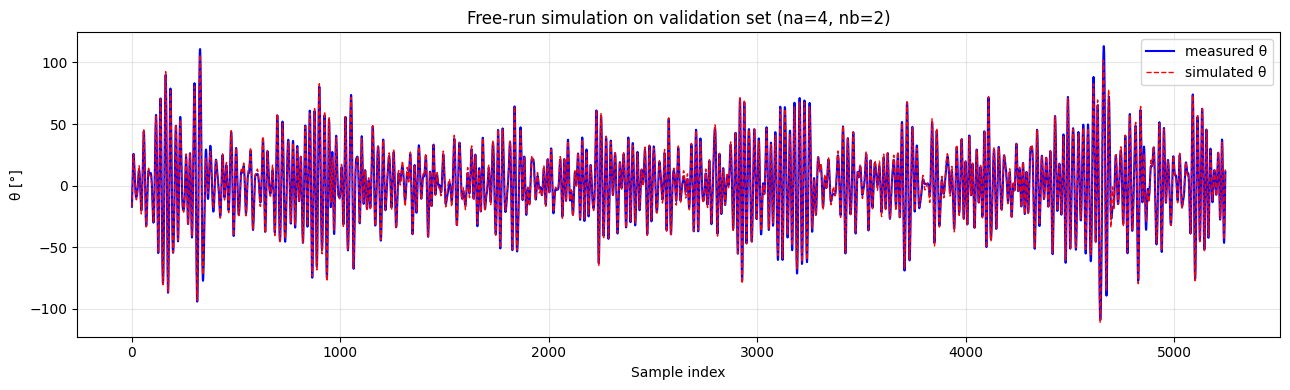

In [16]:
def simulate(model, u, th_init, na, nb):
    """Free-run simulation: predicted angles are fed back instead of true angles."""
    n = len(u)
    th_pred = np.zeros(n)
    th_pred[:na] = th_init[:na]  # seed with true values
 
    start = max(na, nb)
    for k in range(start, n):
        # ascending order, past only — matches make_training_data fix
        th_feat = [th_pred[k-na+i] for i in range(na)]  # [th(k-na), ..., th(k-1)]
        u_feat  = [u[k-nb+i]       for i in range(nb)]  # [u(k-nb),  ..., u(k-1)]
        x = np.array([th_feat + u_feat])
        th_pred[k] = model.predict(x)[0].flatten()[0]
 
    return th_pred[start:]
N_sim = th_val.shape[0]  # keep short — each step is a separate predict call
start = max(na, nb)

th_sim  = simulate(m_sparse, u_val[:N_sim], th_val[:N_sim], na, nb)
th_true = th_val[start:N_sim]

print(f"Simulation BFR:  {BFR(th_true, th_sim):.1f}%")
print(f"Simulation RMSE: {RMSE(th_true, th_sim):.4f} rad  ({np.degrees(RMSE(th_true, th_sim)):.2f}°)")
print('NRMS:', np.mean((th_sim-th_true)**2)**0.5/th_sim.std()*100,'%')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(np.degrees(th_true), 'b', lw=1.5, label='measured θ')
ax.plot(np.degrees(th_sim),  'r--', lw=1,  label='simulated θ')
ax.set_xlabel("Sample index")
ax.set_ylabel("θ [°]")
ax.set_title(f"Free-run simulation on validation set (na={na}, nb={nb})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

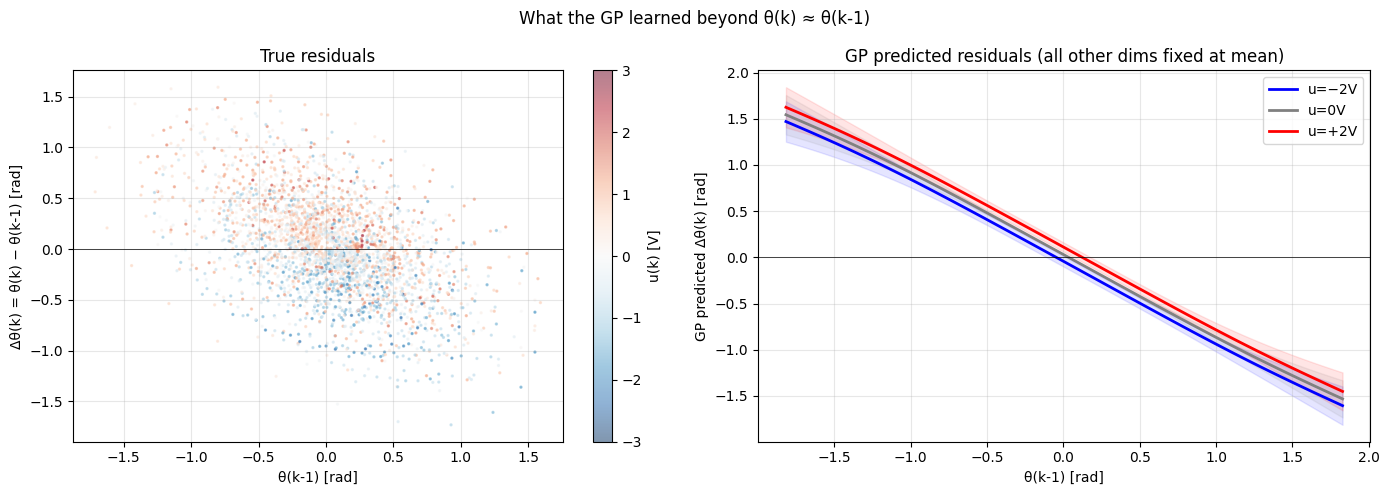

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True residuals from data
delta_th = Ytrain - Xtrain[:, 0]  # θ(k) − θ(k-1)

# Left: scatter of true residuals coloured by u(k)
sc = axes[0].scatter(Xtrain[:3000, 0], delta_th[:3000],
                     c=Xtrain[:3000, na], cmap='RdBu_r',
                     s=2, alpha=0.5, vmin=-3, vmax=3)
plt.colorbar(sc, ax=axes[0], label='u(k) [V]')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('θ(k-1) [rad]')
axes[0].set_ylabel('Δθ(k) = θ(k) − θ(k-1) [rad]')
axes[0].set_title('True residuals')
axes[0].grid(alpha=0.3)

# Right: GP predicted residuals for 3 fixed u values
th_grid = np.linspace(Xtrain[:, 0].min(), Xtrain[:, 0].max(), 100)
X_mean  = Xtrain[:3000].mean(axis=0)

for u_val_i, col, lbl in zip([-2, 0, 2], ['blue', 'gray', 'red'], ['u=−2V', 'u=0V', 'u=+2V']):
    X_line = np.tile(X_mean, (100, 1))
    X_line[:, 0]  = th_grid   # vary θ(k-1)
    X_line[:, na] = u_val_i     # set u(k)

    mu, var = m_sparse.predict(X_line)
    std = np.sqrt(var).flatten()
    delta_mu = mu.flatten() - th_grid  # subtract trivial part

    axes[1].plot(th_grid, delta_mu, color=col, lw=2, label=lbl)
    axes[1].fill_between(th_grid, delta_mu - 2*std, delta_mu + 2*std,
                         color=col, alpha=0.1)

axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('θ(k-1) [rad]')
axes[1].set_ylabel('GP predicted Δθ(k) [rad]')
axes[1].set_title('GP predicted residuals (all other dims fixed at mean)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('What the GP learned beyond θ(k) ≈ θ(k-1)', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
### Prepare submission file for hidden test set prediction
rel_path = 'gym-unbalanced-disk-master/disc-benchmark-files/'
pred_data = np.load(rel_path+'hidden-test-prediction-submission-file.npz')
u_test = pred_data['upast']  # shape (N_test,)
th_test = pred_data['thpast']  # shape (N_test,)

x_test = np.concatenate([th_test[:,15-na:], u_test[:,15-nb:]], axis=1)
Ypred, Ystd = m_sparse.predict(x_test)
th_now_test = Ypred.flatten()

np.savez('my-prediction-submission.npz', upast=u_test, thpast=th_test, thnow=th_now_test)

In [19]:
### Prepare submission file for hidden test set prediction
rel_path = 'gym-unbalanced-disk-master/disc-benchmark-files/'
sim_data = np.load(rel_path+'hidden-test-simulation-submission-file.npz')
u_test = sim_data['u']  # shape (N_test,)
th_test = sim_data['th']  # shape (N_test,)

th_sim_test = simulate(m_sparse, u_test, th_test, na, nb)

np.savez('my-simulation-submission.npz', u=u_test, th=th_sim_test)